# Un robot humanoide operó en un laboratorio de cirugía. ¿Qué tan bien lo hizo?

Le pusieron a un humanoide de propósito general las mismas dos pruebas que un cirujano
hace para certificarse en laparoscopia. Al lado, el da Vinci —el robot quirúrgico de
2,5 millones de dólares— y una mano humana con instrumentos. Los tres, la misma tarea.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper**: [In vivo feasibility study of humanoid robots in surgery](https://doi.org/10.1038/s41586-026-10796-x)
· *Nature* (2026)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-08-humanoides-cirugia-laparoscopica/notebook.ipynb)

**Video**: _Pendiente_


## Qué midieron

El equipo tomó un humanoide comercial y le montó un sistema de teleoperación: una persona
mueve las manos, el robot copia el gesto sujetando instrumentos laparoscópicos normales.
Con ese montaje corrieron dos pruebas estándar del examen de laparoscopia (FLS):

- **Peg transfer** — mover piezas de un pin a otro. Mide velocidad y control grueso.
- **O-ring transfer** — pasar anillos entre postes. Mide precisión fina.

Compararon el humanoide contra el **da Vinci / dVRK** (el estándar quirúrgico) y contra
la **laparoscopia manual**. Participaron desde novatos hasta cirujanos con experiencia.
Los datos que exploramos son del *dry-lab* —fuera del cuerpo—; el paper también reporta
pruebas *in vivo* en cerdos, que no están en el dataset público.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_DAVINCI  = '#2563EB'   # da Vinci / dVRK — estándar establecido
COLOR_HUMANOID = '#7C3AED'   # el humanoide — la plataforma nueva
COLOR_MANUAL   = '#D97706'   # laparoscopia manual
FUENTE = 'Fuente: Nature (2026), doi:10.1038/s41586-026-10796-x | Datos: Zenodo 20434260'

# Pesos oficiales de error del o-ring (del paper) — modifica para re-puntuar
ERROR_WEIGHTS = {1: 2, 2: 2, 3: 4, 4: 5, 5: 3, 6: 3}

import os, urllib.request
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-07-08-humanoides-cirugia-laparoscopica'

# Estilo CaM (local -> /tmp -> GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/../../cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de CSVs — local si existe (contenedor/repo), si no descarga (Colab)
os.makedirs('datos', exist_ok=True)
def cargar(nombre):
    ruta = f'datos/{nombre}'
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(f'{BASE}/datos/{nombre}', ruta)
    return pd.read_csv(ruta)

peg  = cargar('peg_transfer_data.csv')
oring = cargar('oring_transfer_data.csv')

# --- Derivados o-ring: error ponderado y por-intento ---
oring['weighted_error'] = sum(oring[f'Error {i} Total'] * ERROR_WEIGHTS[i] for i in range(1, 7))
oring['tiempo_intento'] = oring['Total Time (s)'] / oring['Num Trials']
oring['error_intento']  = oring['weighted_error'] / oring['Num Trials']
oring['es_cirujano']    = oring['Notes'].astype(str).str.contains('Surgeon')

PLAT = ['da Vinci', 'Humanoid', 'Manual']       # peg usa 'Modality'
PLAT_O = ['dVRK', 'Humanoid', 'Manual']          # o-ring usa 'Platform'
COLS = {'da Vinci': COLOR_DAVINCI, 'dVRK': COLOR_DAVINCI,
        'Humanoid': COLOR_HUMANOID, 'Manual': COLOR_MANUAL}

print(f'Peg transfer  : {peg["Participant"].nunique()} participantes, {len(peg)} filas')
print(f'O-ring transfer: {oring["Participant"].nunique()} participantes, {len(oring)} filas')
print(f'Cirujanos en o-ring: {oring[oring.es_cirujano]["Participant"].nunique()}')
print()
print('Medianas de duración peg (s):')
for m in PLAT:
    print(f'  {m:9s}: {peg[peg["Modality"]==m]["Duration (s)"].median():.0f}')


Peg transfer  : 13 participantes, 39 filas
O-ring transfer: 18 participantes, 54 filas
Cirujanos en o-ring: 6

Medianas de duración peg (s):
  da Vinci : 102
  Humanoid : 351
  Manual   : 696


## Aquí está la primera prueba.

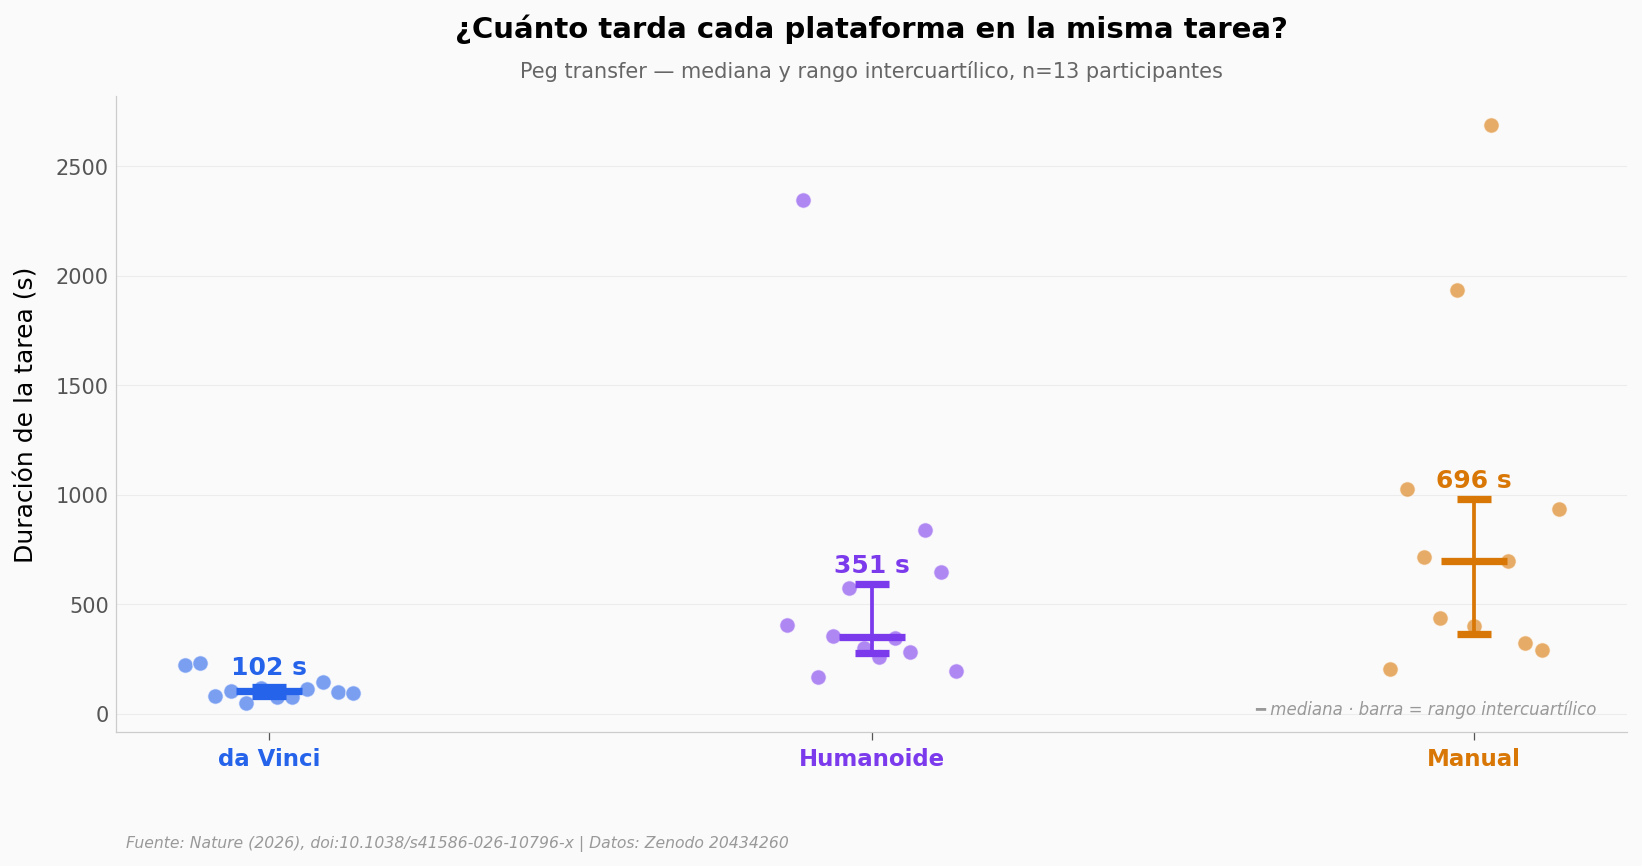

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)
posiciones = [0, 1, 2]
for i, m in enumerate(PLAT):
    vals = peg[peg['Modality'] == m]['Duration (s)'].dropna().values
    n = len(vals)
    x = np.linspace(posiciones[i] - 0.14, posiciones[i] + 0.14, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=COLS[m], s=55, alpha=0.6,
               edgecolors='white', linewidths=0.6, zorder=5)
    mediana = np.median(vals)
    q1, q3 = np.percentile(vals, [25, 75])
    ax.errorbar(posiciones[i], mediana, yerr=[[mediana - q1], [q3 - mediana]],
                fmt='_', color=COLS[m], markersize=32, markeredgewidth=3.5,
                capsize=8, capthick=2, zorder=6)
    ax.text(posiciones[i], q3 + 55, f'{mediana:.0f} s', ha='center',
            fontsize=12, fontweight='bold', color=COLS[m])

ax.set_xticks(posiciones)
ax.set_xticklabels(['da Vinci', 'Humanoide', 'Manual'], fontsize=11, fontweight='bold')
for tick, m in zip(ax.get_xticklabels(), PLAT):
    tick.set_color(COLS[m])
ax.set_ylabel('Duración de la tarea (s)')
ax.set_title('¿Cuánto tarda cada plataforma en la misma tarea?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Peg transfer — mediana y rango intercuartílico, n=13 participantes',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ mediana · barra = rango intercuartílico', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_peg_duracion.png', dpi=200, bbox_inches='tight')
plt.show()


El humanoide queda **en el medio**: su mediana (351 s) es unas 3,4 veces más lenta
que el da Vinci (102 s), pero también unas 2 veces más rápida que la mano humana con
instrumentos (696 s). No compite con el robot quirúrgico dedicado —todavía— pero ya
le gana a la técnica manual en velocidad, usando instrumentos de propósito general.


## Velocidad es una cosa. ¿Y la precisión?

La segunda prueba, el o-ring, castiga los errores: cada tipo de fallo pesa distinto
(soltar el anillo, tocar donde no, salirse del campo). El paper suma esos errores con
pesos fijos. Veamos cuántos comete cada plataforma **por intento**.


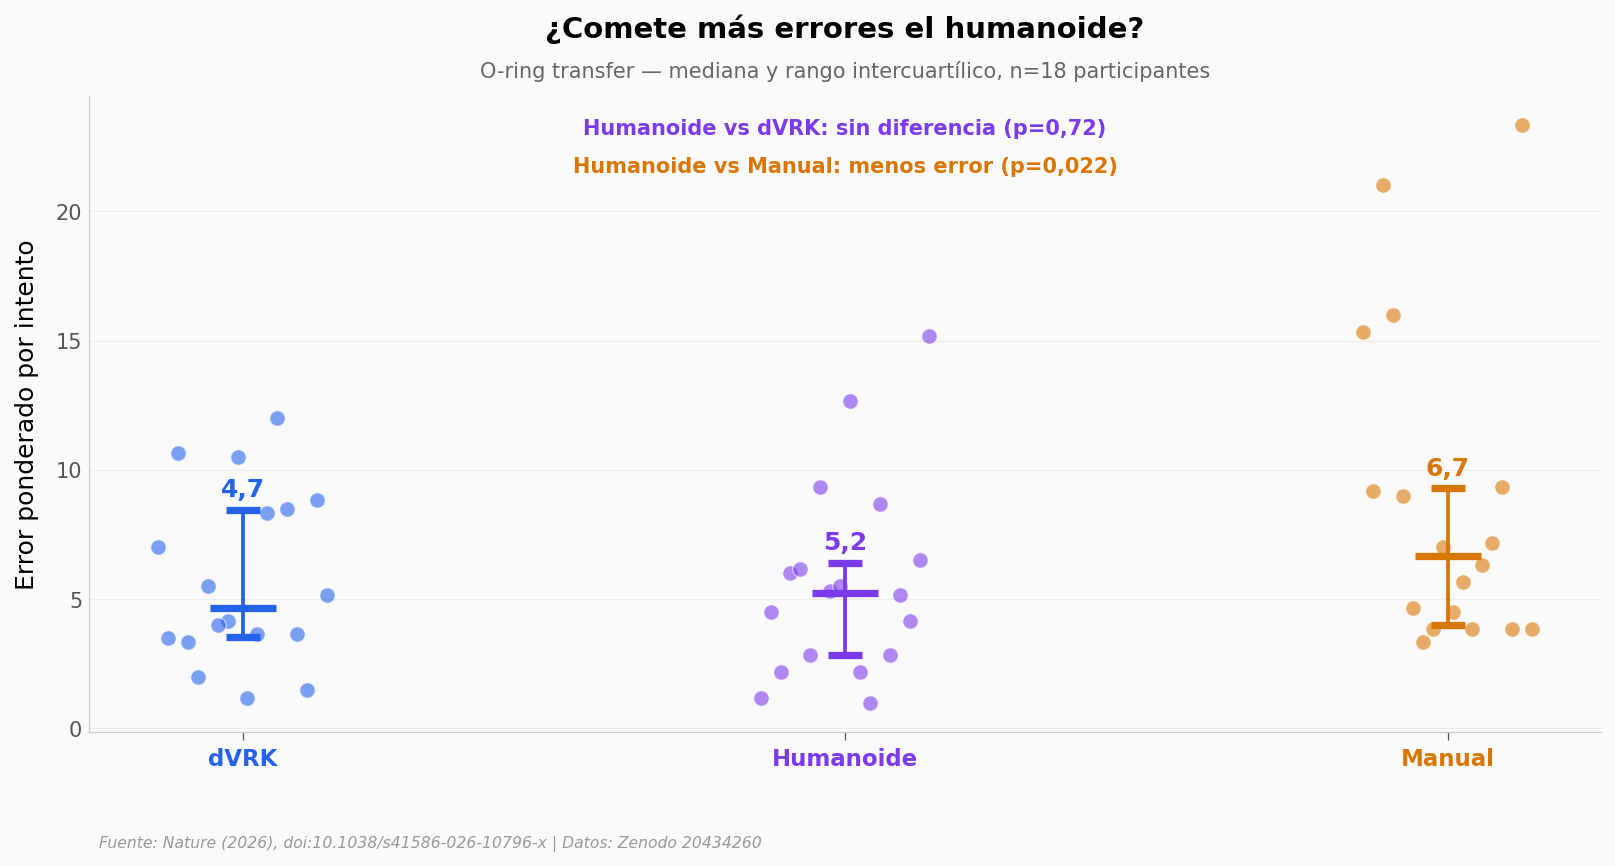

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)
posiciones = [0, 1, 2]
piv = oring.pivot_table(index='Participant', columns='Platform', values='error_intento')
for i, m in enumerate(PLAT_O):
    vals = oring[oring['Platform'] == m]['error_intento'].dropna().values
    n = len(vals)
    x = np.linspace(posiciones[i] - 0.14, posiciones[i] + 0.14, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=COLS[m], s=55, alpha=0.6,
               edgecolors='white', linewidths=0.6, zorder=5)
    mediana = np.median(vals)
    q1, q3 = np.percentile(vals, [25, 75])
    ax.errorbar(posiciones[i], mediana, yerr=[[mediana - q1], [q3 - mediana]],
                fmt='_', color=COLS[m], markersize=32, markeredgewidth=3.5,
                capsize=8, capthick=2, zorder=6)
    ax.text(posiciones[i], q3 + 0.5, f'{mediana:.1f}'.replace('.', ','), ha='center',
            fontsize=12, fontweight='bold', color=COLS[m])

# Wilcoxon pareado (mismo participante en cada plataforma)
p_hd = stats.wilcoxon(piv['Humanoid'], piv['dVRK']).pvalue
p_hm = stats.wilcoxon(piv['Humanoid'], piv['Manual']).pvalue
ax.annotate(f'Humanoide vs dVRK: sin diferencia (p={p_hd:.2f})'.replace('.', ','),
            xy=(0.5, 0.94), xycoords='axes fraction', ha='center',
            fontsize=10, color=COLOR_HUMANOID, fontweight='bold')
ax.annotate(f'Humanoide vs Manual: menos error (p={p_hm:.3f})'.replace('.', ','),
            xy=(0.5, 0.88), xycoords='axes fraction', ha='center',
            fontsize=10, color=COLOR_MANUAL, fontweight='bold')

ax.set_xticks(posiciones)
ax.set_xticklabels(['dVRK', 'Humanoide', 'Manual'], fontsize=11, fontweight='bold')
for tick, m in zip(ax.get_xticklabels(), PLAT_O):
    tick.set_color(COLS[m])
ax.set_ylabel('Error ponderado por intento')
ax.set_title('¿Comete más errores el humanoide?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'O-ring transfer — mediana y rango intercuartílico, n=18 participantes',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/oring_error.png', dpi=200, bbox_inches='tight')
plt.show()


En precisión, el humanoide **empata** con el dVRK: la diferencia de error no es
estadísticamente distinguible. Y comete menos errores que la mano manual. Lo lento que
es no lo vuelve torpe.

Queda una pregunta: ¿quién estaba moviendo el humanoide? Porque manejarlo no es gratis.


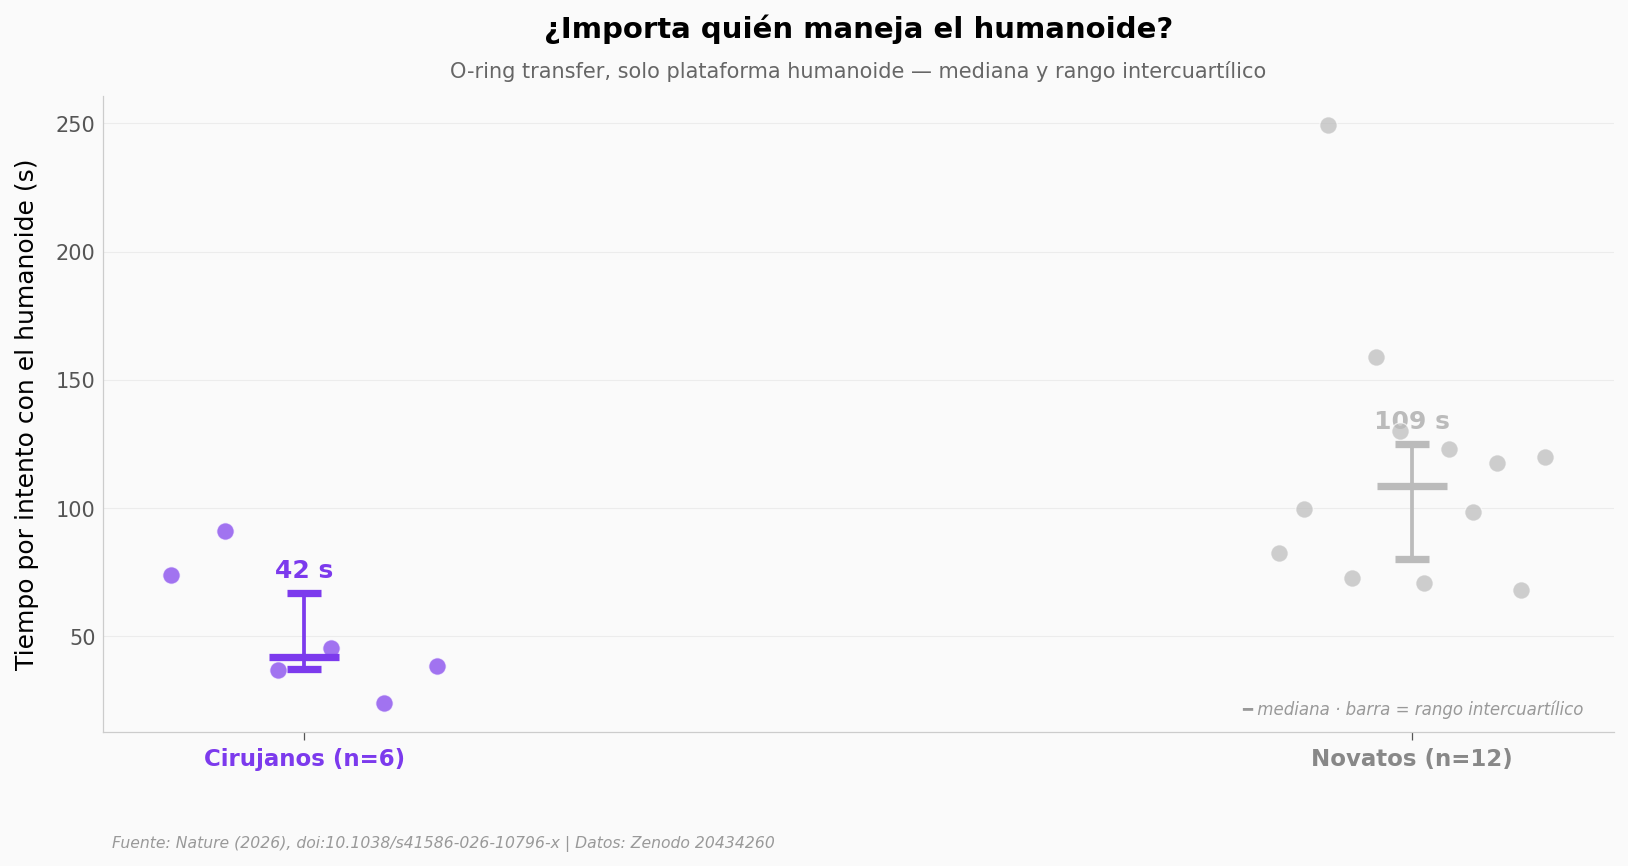

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)
h = oring[oring['Platform'] == 'Humanoid']
grupos = [('Cirujanos', h[h.es_cirujano]['tiempo_intento'].dropna().values, COLOR_HUMANOID),
          ('Novatos',   h[~h.es_cirujano]['tiempo_intento'].dropna().values, '#BBBBBB')]
posiciones = [0, 1]
for i, (nombre, vals, color) in enumerate(grupos):
    n = len(vals)
    x = np.linspace(posiciones[i] - 0.12, posiciones[i] + 0.12, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=color, s=70, alpha=0.7,
               edgecolors='white', linewidths=0.6, zorder=5)
    mediana = np.median(vals)
    q1, q3 = np.percentile(vals, [25, 75])
    ax.errorbar(posiciones[i], mediana, yerr=[[mediana - q1], [q3 - mediana]],
                fmt='_', color=color, markersize=34, markeredgewidth=3.5,
                capsize=8, capthick=2, zorder=6)
    ax.text(posiciones[i], q3 + 6, f'{mediana:.0f} s', ha='center',
            fontsize=12, fontweight='bold', color=color)

ax.set_xticks(posiciones)
ax.set_xticklabels([f'Cirujanos (n={len(grupos[0][1])})',
                    f'Novatos (n={len(grupos[1][1])})'], fontsize=11, fontweight='bold')
ax.get_xticklabels()[0].set_color(COLOR_HUMANOID)
ax.get_xticklabels()[1].set_color('#888888')
ax.set_ylabel('Tiempo por intento con el humanoide (s)')
ax.set_title('¿Importa quién maneja el humanoide?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'O-ring transfer, solo plataforma humanoide — mediana y rango intercuartílico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ mediana · barra = rango intercuartílico', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/experiencia.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Qué tan lejos está el mejor humano del robot dedicado?

Con el humanoide, los cirujanos tardan menos de la mitad que los novatos: parece que la
destreza quirúrgica se transfiere al mando del robot. Ojo: son grupos chicos (6 vs 12), así
que es una pista, no un veredicto. Pongamos a todos los participantes en una misma
distribución y veamos dónde cae cada uno frente a la referencia del dVRK.


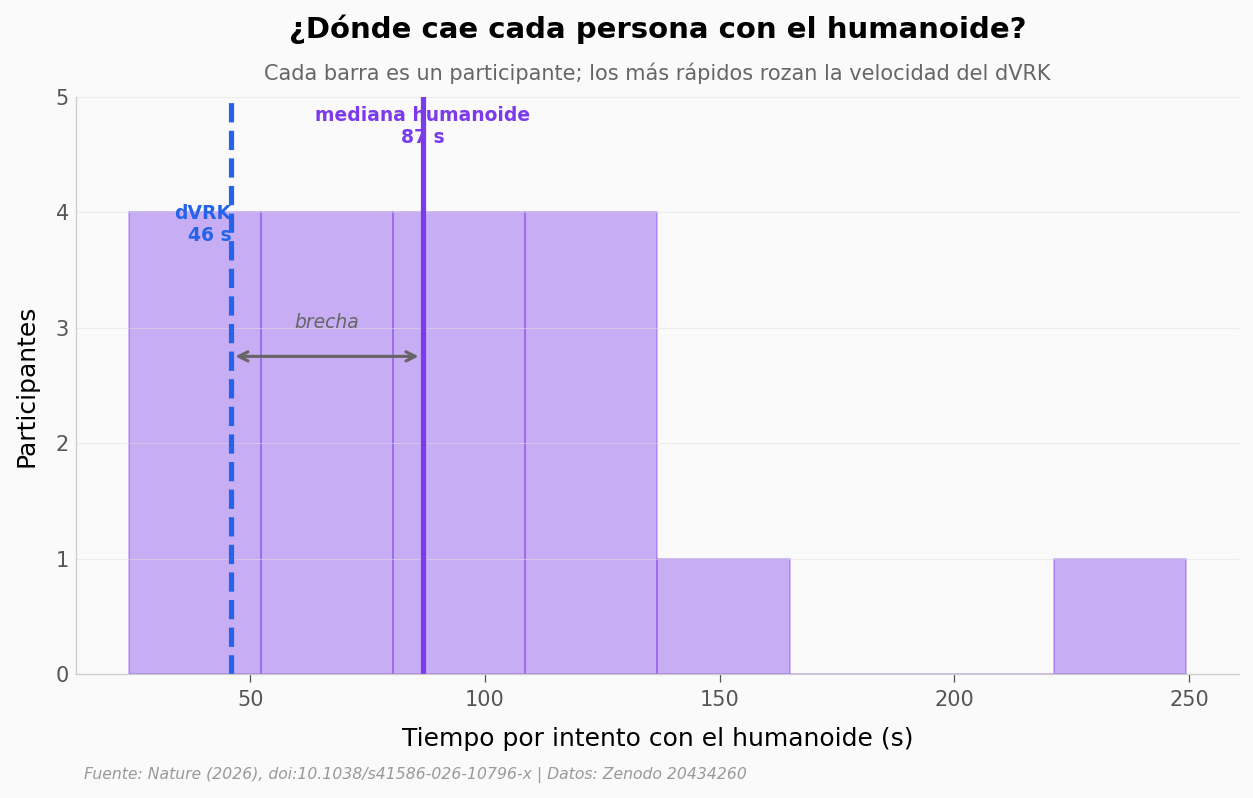

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
h_tiempos = oring[oring['Platform'] == 'Humanoid']['tiempo_intento'].dropna().values
media_h = np.median(h_tiempos)
ref_dvrk = oring[oring['Platform'] == 'dVRK']['tiempo_intento'].median()   # 45,9 s
ref_cir  = oring[(oring['Platform'] == 'Humanoid') & oring['es_cirujano']]['tiempo_intento'].median()

n, bins, patches = ax.hist(h_tiempos, bins=8, color=COLOR_HUMANOID, alpha=0.4,
                           edgecolor=COLOR_HUMANOID, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)
ax.axvline(x=media_h, color=COLOR_HUMANOID, linewidth=2.5)
ax.text(media_h, y_max * 0.92, f'mediana humanoide\n{media_h:.0f} s'.replace('.', ','),
        color=COLOR_HUMANOID, fontsize=9, fontweight='bold', ha='center')
ax.axvline(x=ref_dvrk, color=COLOR_DAVINCI, linewidth=2.5, linestyle='--')
ax.text(ref_dvrk, y_max * 0.75, f'dVRK\n{ref_dvrk:.0f} s'.replace('.', ','),
        color=COLOR_DAVINCI, fontsize=9, fontweight='bold', ha='right')
ax.annotate('', xy=(ref_dvrk, y_max * 0.55), xytext=(media_h, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((ref_dvrk + media_h) / 2, y_max * 0.6, 'brecha', color='#666666',
        fontsize=9, ha='center', style='italic')

ax.set_xlabel('Tiempo por intento con el humanoide (s)')
ax.set_ylabel('Participantes')
ax.set_title('¿Dónde cae cada persona con el humanoide?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada barra es un participante; los más rápidos rozan la velocidad del dVRK',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_humanoide.png', dpi=200, bbox_inches='tight')
plt.show()


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El humanoide es más lento que el da Vinci en peg transfer | ✅ | Mediana 351 s vs 102 s (~3,4×). Pareado: dz=0,82, Wilcoxon p=0,001, n=11 |
| El humanoide es más rápido que la laparoscopia manual (peg) | ✅ | Mediana 351 s vs 696 s (~2×). Pareado: dz=-0,83, p=0,010, n=11 |
| La precisión del humanoide iguala a la del dVRK (o-ring) | ✅ | Error ponderado/intento: dz=-0,04, Wilcoxon p=0,72 → sin diferencia detectable, n=18 |
| El humanoide comete menos error que el manual (o-ring) | ⚠️ | Mediana 5,2 vs 6,7; dz=-0,62, p=0,022. Real pero efecto moderado |
| Los cirujanos manejan el humanoide más rápido que los novatos | ✅ | Mediana 41,9 s vs 108,7 s por intento. Diferencia descriptiva, grupos pequeños (6 vs 12) |

> **Limitaciones:** son tareas de laboratorio (*dry-lab*), no cirugía en un paciente. Muestras
> pequeñas (n=13 y n=18) con varios casos incompletos en peg. El humanoide es *teleoperado*
> —una persona lo dirige, no opera solo—. El paper lo enmarca como estudio de **viabilidad
> técnica**, no de eficacia clínica: aún hay retos por resolver antes de cualquier uso real.
> Los estudios *in vivo* en cerdos que menciona el abstract no están en este dataset.


## Ahora tú

1. **¿Y si solo miras a los cirujanos?** En la celda de abajo, cambia `SOLO_CIRUJANOS`
   a `True` y observa cómo se mueve la mediana del humanoide frente al dVRK.
2. **¿Cambia la historia con otros pesos de error?** Los `ERROR_WEIGHTS` de la celda de
   configuración son los del paper. Súbele el peso al error 4 (el más grave) y recalcula.
3. **¿Qué tan disparejo es el humanoide?** Compara el rango intercuartílico del humanoide
   contra el del dVRK — ¿cuál es más consistente entre personas?


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Cambia este valor y vuelve a ejecutar la celda
SOLO_CIRUJANOS = False   # <- prueba con True

sub = oring[oring.es_cirujano] if SOLO_CIRUJANOS else oring
etiqueta = 'solo cirujanos' if SOLO_CIRUJANOS else 'todos los participantes'
print(f'Tiempo por intento — medianas ({etiqueta}):')
for m in PLAT_O:
    vals = sub[sub['Platform'] == m]['tiempo_intento'].dropna()
    print(f'  {m:9s}: {vals.median():5.1f} s   (n={len(vals)})')

brecha = (sub[sub.Platform=='Humanoid']['tiempo_intento'].median()
          / sub[sub.Platform=='dVRK']['tiempo_intento'].median())
print(f'\nEl humanoide es {brecha:.1f}x el tiempo del dVRK'.replace('.', ','))


Tiempo por intento — medianas (todos los participantes):
  dVRK     :  45.9 s   (n=18)
  Humanoid :  86.8 s   (n=18)
  Manual   :  61.8 s   (n=18)

El humanoide es 1,9x el tiempo del dVRK


## Fuentes

**Paper**: [In vivo feasibility study of humanoid robots in surgery](https://doi.org/10.1038/s41586-026-10796-x)  
*Nature, 2026-07-08*

**Datos**: [User Performance Data Sheets (humanoid laparoscopic surgery user study)](https://zenodo.org/records/20434260)

**Referencias citadas**: [Laparoscopic Humanoid Code (g1 teleoperation framework)](https://zenodo.org/records/18023650)

*13 afirmaciones del notebook verificadas contra estas fuentes*